In [2]:
import os, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

label_map = {"A":0,"B1":1,"B2":2,"B4":3,"B6":4,"G":5}
NUM_CLASSES = 6

MAX_LEN = 300
BATCH_SIZE = 8
EPOCHS = 15
LR = 7e-6 

RGB_TRAIN  = r"datasets/i3d-features/RGB"
FLOW_TRAIN = r"datasets/i3d-features/Flow"
AUDIO_TRAIN = r"datasets/vggish-features/train"

RGB_TEST  = r"datasets/i3d-features/RGBTest"
FLOW_TEST = r"datasets/i3d-features/FlowTest"
AUDIO_TEST = r"datasets/vggish-features/test"

MODEL_PATH = "./final_model.pth"

In [4]:
def extract_key(f):
    base = "_".join(f.split("_")[:-1])

    m = re.search(r'#(\d{2}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})', f)

    if m:
        duration = m.group(1) + "_" + m.group(2)
    else:
        return None  # skip bad files

    return (base, duration)

In [5]:
def extract_labels(name):
    y = torch.zeros(NUM_CLASSES)
    m = re.search(r'label_([^_]+)', name)
    if m:
        for p in m.group(1).split('-'):
            if p in label_map:
                y[label_map[p]] = 1
    return y

In [6]:
def process_sequence(x, target_len, dim):
    if len(x) >= target_len:
        idx = np.linspace(0, len(x)-1, target_len).astype(int)
        return x[idx]
    else:
        pad = np.zeros((target_len-len(x), dim))
        return np.vstack([x, pad])

In [7]:
class MultiModalDataset(Dataset):
    def __init__(self, rgb, flow, audio):

        self.rgb_path = rgb
        self.flow_path = flow
        self.audio_path = audio

        self.rgb_dict, self.flow_dict, self.audio_dict = {}, {}, {}

        for f in os.listdir(rgb):
            key = extract_key(f)
            if key is not None:
                self.rgb_dict.setdefault(key, []).append(f)

        for f in os.listdir(flow):
            key = extract_key(f)
            if key is not None:
                self.flow_dict.setdefault(key, []).append(f)

        for f in os.listdir(audio):
            key = extract_key(f)
            if key is not None:
                self.audio_dict[key] = f

        self.keys = [
            k for k in self.rgb_dict
            if k in self.flow_dict and k in self.audio_dict
        ]

        print("Matched samples:", len(self.keys))

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):

        key = self.keys[idx]

        rgb_files = sorted(self.rgb_dict[key],
            key=lambda x: int(x.split("_")[-1].replace(".npy",""))
        )

        flow_files = sorted(self.flow_dict[key],
            key=lambda x: int(x.split("_")[-1].replace(".npy",""))
        )

        rgb_all, flow_all = [], []

        for r, f in zip(rgb_files, flow_files):

            rgb = np.load(os.path.join(self.rgb_path, r))
            flow = np.load(os.path.join(self.flow_path, f))

            L = min(len(rgb), len(flow))
            rgb_all.append(rgb[:L])
            flow_all.append(flow[:L])

        rgb = np.concatenate(rgb_all)
        flow = np.concatenate(flow_all)

        audio = np.load(os.path.join(self.audio_path, self.audio_dict[key]))

        rgb = process_sequence(rgb, MAX_LEN, 1024)
        flow = process_sequence(flow, MAX_LEN, 1024)
        audio = process_sequence(audio, MAX_LEN, 128)

        rgb = F.normalize(torch.tensor(rgb), dim=-1)
        flow = F.normalize(torch.tensor(flow), dim=-1)
        audio = F.normalize(torch.tensor(audio), dim=-1)

        return rgb.float(), flow.float(), audio.float(), extract_labels(key[0])

In [8]:
dataset = MultiModalDataset(RGB_TRAIN, FLOW_TRAIN, AUDIO_TRAIN)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

test_loader = DataLoader(
    MultiModalDataset(RGB_TEST, FLOW_TEST, AUDIO_TEST),
    batch_size=BATCH_SIZE
)

Matched samples: 2396
Matched samples: 495


In [ ]:
class_weights = torch.tensor([1.0, 1.4, 1.5, 1.0, 1.1, 1.2]).to(DEVICE)

class WeightedFocalBCELoss(nn.Module):
    def __init__(self, weights, gamma=1.8):
        super().__init__()
        self.weights = weights
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = (1 - pt) ** self.gamma * bce
        return (focal * self.weights).mean()

In [ ]:
class Encoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.enc = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(dim, 4, 128, 0.5, batch_first=True),
            num_layers=3
        )

    def forward(self,x):
        return self.enc(x)


class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.rgb_enc = Encoder(1024)
        self.flow_enc = Encoder(1024)
        self.audio_enc = Encoder(128)

        self.rgb_proj = nn.Linear(1024,512)
        self.flow_proj = nn.Linear(1024,512)
        self.audio_proj = nn.Linear(128,512)

        self.fusion = nn.MultiheadAttention(512,4,batch_first=True)

        #  UPDATED DROPOUT HERE ALSO (see next section)
        self.fc = nn.Sequential(
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(0.5),  
            nn.Linear(256,NUM_CLASSES)
        )

        #  NEW: bias for difficult classes
        self.logit_bias = nn.Parameter(
            torch.tensor([1.0, 1.2, 1.3, 1.0, 1.0, 1.2])
        )

    def forward(self,rgb,flow,audio):

        r = self.rgb_proj(self.rgb_enc(rgb))
        f = self.flow_proj(self.flow_enc(flow))
        a = self.audio_proj(self.audio_enc(audio))

        fusion = torch.cat([r,f,a],dim=1)
        fusion,_ = self.fusion(fusion,fusion,fusion)

        fusion = fusion.mean(dim=1)

        logits = self.fc(fusion)

        #  APPLY BIAS
        logits = self.fc(fusion)

      #  scale + bias
        logits = logits * self.logit_scale + self.logit_bias

        return logits

In [ ]:
model = Model().to(DEVICE)
criterion = WeightedFocalBCELoss(class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

best_val = float("inf")
patience = 5
counter = 0

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for i,(rgb,flow,audio,labels) in enumerate(train_bar):

        rgb,flow,audio,labels = rgb.to(DEVICE),flow.to(DEVICE),audio.to(DEVICE),labels.to(DEVICE)

        optimizer.zero_grad()
        out = model(rgb,flow,audio)

        loss = criterion(out,labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()

        train_loss += loss.item()

        train_bar.set_postfix(loss=loss.item(), samples=(i+1)*BATCH_SIZE)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for rgb,flow,audio,labels in val_loader:
            rgb,flow,audio,labels = rgb.to(DEVICE),flow.to(DEVICE),audio.to(DEVICE),labels.to(DEVICE)
            val_loss += criterion(model(rgb,flow,audio),labels).item()

    scheduler.step(val_loss)

    print(f"Train {train_loss:.3f} | Val {val_loss:.3f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch 1/15: 100%|██████████| 240/240 [08:11<00:00,  2.05s/it, loss=0.109, samples=1920] 


Train 45.158 | Val 8.169


Epoch 2/15: 100%|██████████| 240/240 [07:56<00:00,  1.98s/it, loss=0.0787, samples=1920]


Train 27.402 | Val 5.790


Epoch 3/15: 100%|██████████| 240/240 [07:56<00:00,  1.98s/it, loss=0.0764, samples=1920] 


...

Train 9.580 | Val 4.318


Epoch 12/15: 100%|██████████| 240/240 [05:11<00:00,  1.30s/it, loss=0.0014, samples=1920]  


Train 8.561 | Val 4.468


Epoch 13/15: 100%|██████████| 240/240 [06:17<00:00,  1.57s/it, loss=0.11, samples=1920]    


Train 7.910 | Val 4.521
Early stopping


In [12]:
# LOAD BEST MODEL
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for rgb, flow, audio, labels in test_loader:

        rgb = rgb.to(DEVICE)
        flow = flow.to(DEVICE)
        audio = audio.to(DEVICE)

        # forward
        logits = model(rgb, flow, audio)

        #  probabilities
        probs = torch.sigmoid(logits)

        #  threshold (fixed)
        preds = (probs > 0.5).int()

        # store
        all_labels.append(labels.numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

#  convert to numpy
import numpy as np
all_labels = np.vstack(all_labels)
all_preds = np.vstack(all_preds)
all_probs = np.vstack(all_probs)

In [13]:
from sklearn.metrics import classification_report

labels = ["A","B1","B2","B4","B6","G"]

print(classification_report(
    all_labels,
    all_preds,
    target_names=labels,
    zero_division=0
))

              precision    recall  f1-score   support

           A       0.93      0.96      0.94       193
          B1       0.89      0.66      0.76        77
          B2       0.66      0.70      0.68        91
          B4       1.00      0.76      0.86        29
          B6       0.93      0.92      0.92        99
           G       0.56      0.86      0.68        43

   micro avg       0.83      0.85      0.84       532
   macro avg       0.83      0.81      0.81       532
weighted avg       0.85      0.85      0.84       532
 samples avg       0.84      0.86      0.84       532



In [ ]:
from sklearn.metrics import average_precision_score

#  Per-class Average Precision
ap_per_class = average_precision_score(
    all_labels,
    all_probs,
    average=None
)

labels = ["A","B1","B2","B4","B6","G"]

print("🔹 Average Precision per class:\n")
for i, label in enumerate(labels):
    print(f"{label}: {ap_per_class[i]:.4f}")

#  Mean Average Precision (mAP)
mAP = average_precision_score(
    all_labels,
    all_probs,
    average="macro"
)

print("\n Mean Average Precision (mAP):", round(mAP, 4))

🔹 Average Precision per class:

A: 0.9850
B1: 0.8912
B2: 0.7186
B4: 0.9199
B6: 0.9774
G: 0.8192

🔥 Mean Average Precision (mAP): 0.8852


In [15]:
from sklearn.metrics import average_precision_score

mAP = average_precision_score(all_labels, all_probs, average="macro")

print(" Mean Average Precision (mAP):", mAP)

 Mean Average Precision (mAP): 0.8852162842940965


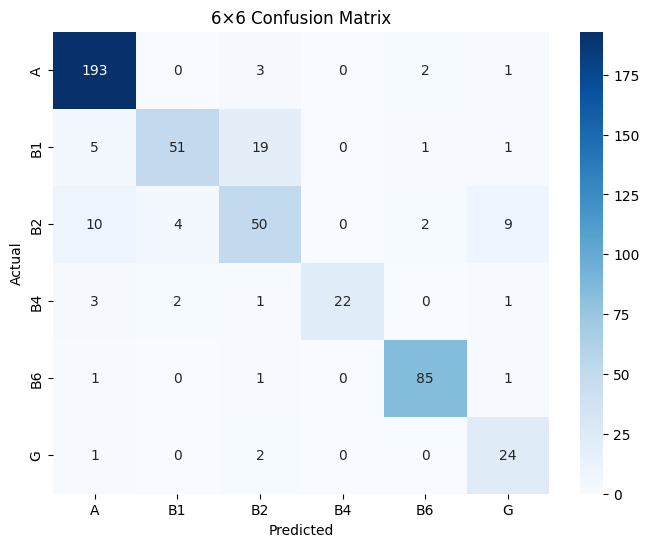

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# convert multi-label → single label (for visualization)
true_classes = np.argmax(all_labels, axis=1)
pred_classes = np.argmax(all_preds, axis=1)

cm = confusion_matrix(true_classes, pred_classes)

labels = ["A","B1","B2","B4","B6","G"]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",   #  blue color as you wanted
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("6×6 Confusion Matrix")

plt.show()